In [5]:
import pandas as pd

In [6]:
# PositionChr2:11531967..11534358 (+ strand)

In [7]:
g1001_cam5 = pd.read_csv('1001genomes.org--Chr2-11531909..11534540.gff3', sep='\t', comment='#', header=None)

In [8]:
g1001_cam5 = g1001_cam5.drop([1, 5,6,7],axis=1)

In [9]:
g1001_cam5[2].unique()

array(['deletion', 'SNV', 'deletion,insertion', 'insertion',
       'insertion,deletion', 'SNV,insertion'], dtype=object)

In [11]:
build = pd.read_csv('../follow_up_sign_blocks//tair_annotations_topr.tsv',sep = '\t')

In [12]:
gfftair = pd.read_csv('../key_files/TAIR10_GFF3_genes_transposons.gff', sep = '\t', header=None)

In [13]:
AT2G27030_tair = gfftair[gfftair[8].str.contains('AT2G27030')]

In [14]:
AT2G27030_tair = AT2G27030_tair.reset_index()

In [15]:
#AT2G27030_tair.to_csv('AT2G27030_tair')

In [16]:
# Here's the full code that includes plotting the gene structure and the significant block.

import pandas as pd
import matplotlib.pyplot as plt

# Select relevant columns
features = AT2G27030_tair[[2, 3, 4, 8]].copy()
features.columns = ['feature_type', 'start', 'end', 'annotation']

# Convert start and end to integers
features['start'] = features['start'].astype(int)
features['end'] = features['end'].astype(int)

# Filter out the exons, UTRs, and mRNAs
exons = features[features['feature_type'] == 'exon']
utr_5 = features[features['feature_type'] == 'five_prime_UTR']
utr_3 = features[features['feature_type'] == 'three_prime_UTR']
mrna = features[features['feature_type'] == 'mRNA']

# Define the significant block region
significant_block_start = 11533904
significant_block_end = 11534263




,feature_type,start,end,annotation
3,exon,11532004,11532144,Parent=AT2G27030.1
6,exon,11532687,11533276,Parent=AT2G27030.1
11,exon,11532007,11534272,Parent=AT2G27030.2
17,exon,11532004,11532144,Parent=AT2G27030.3
20,exon,11532687,11533056,Parent=AT2G27030.3
22,exon,11534077,11534333,Parent=AT2G27030.3


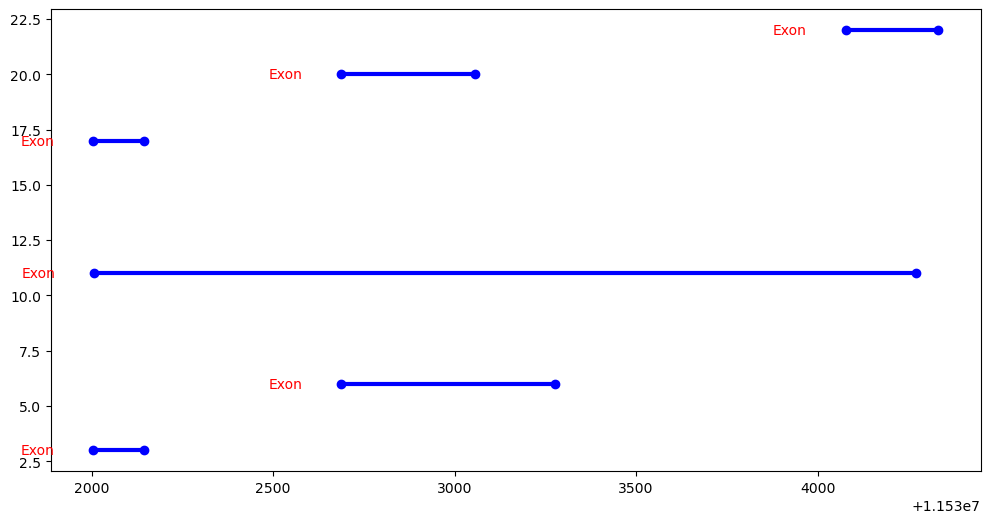

In [18]:
# Plot the gene structure including exons, UTRs, and the significant block
fig, ax = plt.subplots(figsize=(12, 6))

# Plot exons at different Y coordinates
for i, row in exons.iterrows():
    ax.plot([row['start'], row['end']], [i, i], marker='o', color='b', lw=3)
    ax.text(row['start'] - 200, i, 'Exon', verticalalignment='center', color='r')

In [25]:
pd.concat([exons, utr_5,utr_3]).to_csv('cam5_exons_utr.csv',index=None)

In [20]:
utr_5

,feature_type,start,end,annotation
4,five_prime_UTR,11532004,11532068,Parent=AT2G27030.1
12,five_prime_UTR,11532007,11532718,Parent=AT2G27030.2
18,five_prime_UTR,11532004,11532068,Parent=AT2G27030.3


In [21]:
utr_3

,feature_type,start,end,annotation
8,three_prime_UTR,11533061,11533276,Parent=AT2G27030.1
14,three_prime_UTR,11533061,11534272,Parent=AT2G27030.2
24,three_prime_UTR,11534177,11534333,Parent=AT2G27030.3


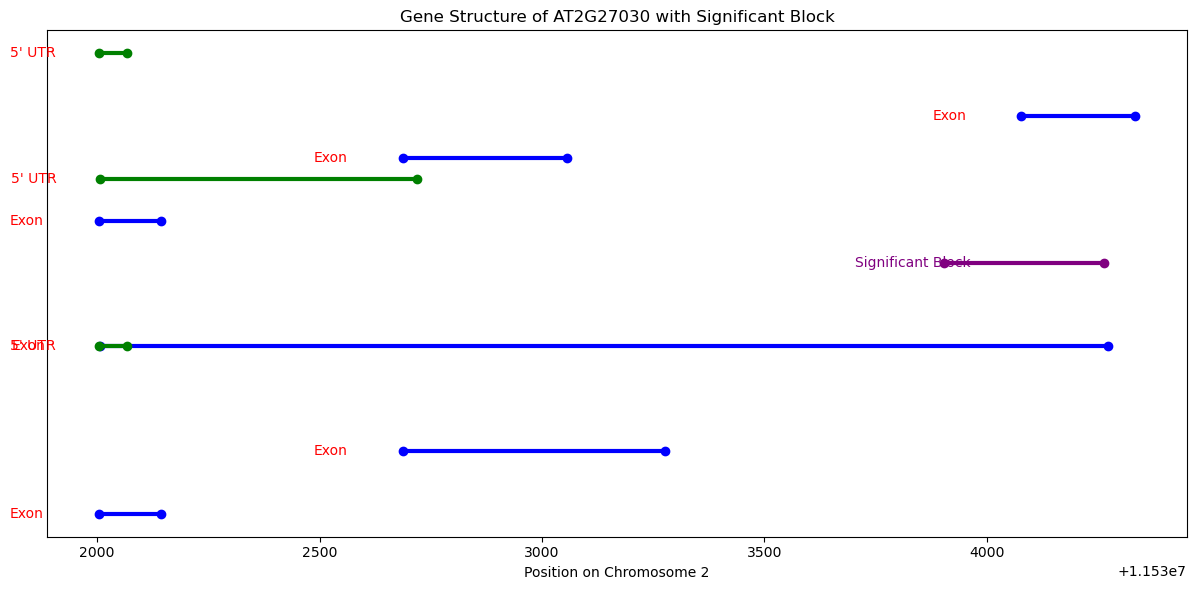

In [19]:
# Adjust the plotting logic to place exons, UTRs, and significant block on different Y coordinates.

# Plot the gene structure including exons, UTRs, and the significant block
fig, ax = plt.subplots(figsize=(12, 6))

# Plot exons at different Y coordinates
for i, row in exons.iterrows():
    ax.plot([row['start'], row['end']], [i, i], marker='o', color='b', lw=3)
    ax.text(row['start'] - 200, i, 'Exon', verticalalignment='center', color='r')

# Plot 5' UTRs at a higher Y coordinate
for i, row in utr_5.iterrows():
    ax.plot([row['start'], row['end']], [i + len(exons) + 1, i + len(exons) + 1], marker='o', color='g', lw=3)
    ax.text(row['start'] - 200, i + len(exons) + 1, '5\' UTR', verticalalignment='center', color='r')

# Plot 3' UTRs at a higher Y coordinate
for i, row in utr_3.iterrows():
    ax.plot([row['start'], row['end']], [i + len(exons) + len(utr_5) + 2, i + len(exons) + len(utr_5) + 2], marker='o', color='orange', lw=3)
    ax.text(row['start'] - 200, i + len(exons) + len(utr_5) + 2, '3\' UTR', verticalalignment='center', color='r')

# Plot the significant block on top, at an even higher Y coordinate
ax.plot([significant_block_start, significant_block_end], [len(exons) + len(utr_5) + len(utr_3) + 3, len(exons) + len(utr_5) + len(utr_3) + 3], 
        marker='o', color='purple', lw=3, label='Significant Block')
ax.text(significant_block_start - 200, len(exons) + len(utr_5) + len(utr_3) + 3, 'Significant Block', verticalalignment='center', color='purple')

# Add labels and title
ax.set_yticks([])
ax.set_xlabel('Position on Chromosome 2')
ax.set_title('Gene Structure of AT2G27030 with Significant Block')

plt.tight_layout()
plt.show()


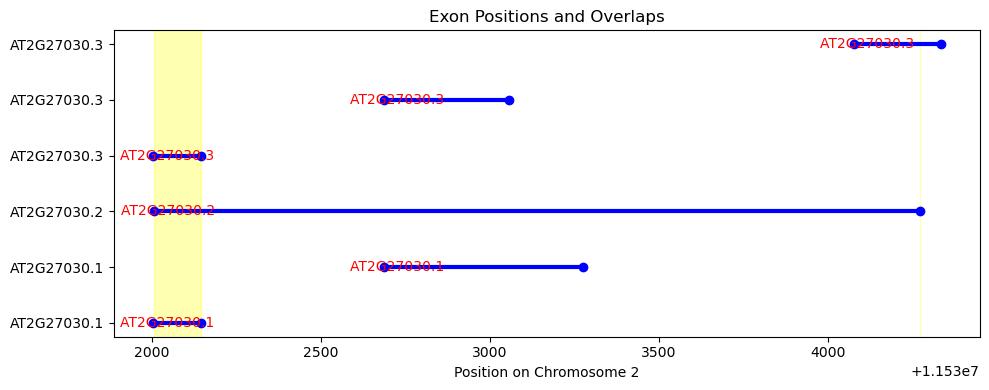

In [68]:
import matplotlib.pyplot as plt

# Exon data: start and end positions
exons = [
    ("AT2G27030.1", 11532004, 11532144),
    ("AT2G27030.1", 11532687, 11533276),
    ("AT2G27030.2", 11532007, 11534272),
    ("AT2G27030.3", 11532004, 11532144),
    ("AT2G27030.3", 11532687, 11533056),
    ("AT2G27030.3", 11534077, 11534333),
]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot lines for each exon
for i, (name, start, end) in enumerate(exons):
    ax.plot([start, end], [i, i], marker='o', color='b', lw=3)
    ax.text(start - 100, i, f'{name} ', verticalalignment='center', color='r')
    #ax.text(end + 100, i, f'({end})', verticalalignment='center', color='r')

# Add labels and title
ax.set_yticks(range(len(exons)))
ax.set_yticklabels([name for name, _, _ in exons])
ax.set_xlabel('Position on Chromosome 2')
ax.set_title('Exon Positions and Overlaps')

# Highlight overlaps (between Exon 1 & Exon 2, and Exon 4 & Exon 5)
ax.axvspan(11532007, 11532144, color='yellow', alpha=0.3)  # Exon 1 & Exon 2 overlap
ax.axvspan(11534272, 11534272, color='yellow', alpha=0.3)  # Exon 4 & Exon 5 overlap

plt.tight_layout()
plt.show()


In [32]:
build[build['gene_symbol'] == 'AT2G27030']

,chrom,gene_start,gene_end,gene_symbol,biotype,exon_chromstart,exon_chromend
9599,2,11532004,11534333,AT2G27030,protein_coding_gene,"11532004,11532007,11532687,11534077","11532144,11533056,11533276,11534272,11534333"
